# Uplift Modeling: Core Models

This notebook keeps only the top-performing configurations for:
S-Learner, T-Learner, Class Transformation, X-Learner, R-Learner.
Structure and metrics follow `modeling.ipynb` (plots + uplift metrics).


In [65]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_predict, KFold
from sklearn.linear_model import LinearRegression


In [66]:
def asd_score(y_true, uplift_pred, treatment, n_bins=10):
    df = pd.DataFrame({
        "y": np.asarray(y_true),
        "uplift": np.asarray(uplift_pred),
        "treatment": np.asarray(treatment),
    })
    df["decile"] = pd.qcut(
        df["uplift"].rank(method="first"),
        q=n_bins,
        labels=False,
        duplicates="drop",
    )
    sq = []
    for _, grp in df.groupby("decile"):
        trt = grp[grp["treatment"] == 1]["y"]
        ctrl = grp[grp["treatment"] == 0]["y"]
        if len(trt) == 0 or len(ctrl) == 0:
            continue
        sq.append((trt.mean() - ctrl.mean() - grp["uplift"].mean()) ** 2)
    return float(np.mean(sq)) if sq else np.nan

def decile_stats(pred, y, t, n_bins=10):
    df = pd.DataFrame({"pred": np.asarray(pred), "y": np.asarray(y), "t": np.asarray(t)})
    df["bin"] = pd.qcut(
        df["pred"].rank(method="first"),
        q=n_bins,
        labels=False,
        duplicates="drop",
    )
    rows = []
    for b in sorted(df["bin"].unique()):
        g = df[df["bin"] == b]
        cr_t = g.loc[g["t"] == 1, "y"].mean()
        cr_c = g.loc[g["t"] == 0, "y"].mean()
        rows.append({"Decile": int(b) + 1, "CR_T": cr_t, "CR_C": cr_c, "Uplift": cr_t - cr_c})
    return pd.DataFrame(rows)


In [67]:
import sklearn.utils
from sklearn.utils._plotting import check_matplotlib_support
sklearn.utils.check_matplotlib_support = check_matplotlib_support

from sklift.models import SoloModel, TwoModels, ClassTransformation
from sklift.metrics import (
    qini_auc_score,
    uplift_auc_score,
    uplift_at_k,
    weighted_average_uplift,
    qini_curve,
    uplift_curve,
)


In [68]:
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()
treatment_train = pd.read_csv("data/processed/treatment_train.csv").squeeze()
treatment_test = pd.read_csv("data/processed/treatment_test.csv").squeeze()

treatment_train = (treatment_train == "test").astype(int)
treatment_test = (treatment_test == "test").astype(int)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Treatment rate: train={treatment_train.mean():.4f}, test={treatment_test.mean():.4f}")


Train: (480920, 244), Test: (206109, 244)
Treatment rate: train=0.7509, test=0.7509


In [69]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import Ridge
from causalml.inference.meta import BaseXRegressor, BaseRRegressor

cat_params = dict(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    random_state=42,
    silent=True,
)

lgbm_ct_params = dict(
    n_estimators=500,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

lgbm_meta_params = dict(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

predictions = {}
predictions_train = {}
models = {}

In [70]:
sm = SoloModel(
    estimator=CatBoostClassifier(**cat_params),
    method="treatment_interaction",
)
sm.fit(X_train, y_train, treatment_train)
predictions["S-Learner (interaction)"] = sm.predict(X_test)
predictions_train["S-Learner (interaction)"] = sm.predict(X_train)
models["S-Learner (interaction)"] = sm
print("S-Learner (interaction) done")

tm = TwoModels(
    estimator_trmnt=CatBoostClassifier(**cat_params),
    estimator_ctrl=CatBoostClassifier(**cat_params),
    method="ddr_control",
)
tm.fit(X_train, y_train, treatment_train)
predictions["T-Learner (DDR)"] = tm.predict(X_test)
predictions_train["T-Learner (DDR)"] = tm.predict(X_train)
models["T-Learner (DDR)"] = tm
print("T-Learner (DDR) done")


S-Learner (interaction) done
T-Learner (DDR) done


In [71]:
ct_base = ClassTransformation(estimator=LGBMClassifier(**lgbm_ct_params))
ct_base.fit(X_train, y_train, treatment_train)
ct_test = ct_base.predict(X_test)
models["CT base (LGBM)"] = ct_base
print("CT base done")


CT base done


In [72]:
X_tr = X_train.values
X_te = X_test.values
y_tr = y_train.values.astype(float)
t_tr = treatment_train.values.astype(int)

prop_model = LGBMClassifier(**lgbm_meta_params)
p_train = cross_val_predict(prop_model, X_tr, t_tr, cv=3, method="predict_proba")[:, 1]
prop_model.fit(X_tr, t_tr)
p_test = prop_model.predict_proba(X_te)[:, 1]
p_train_full = prop_model.predict_proba(X_tr)[:, 1]
p_train = np.clip(p_train, 0.01, 0.99)
p_test = np.clip(p_test, 0.01, 0.99)
p_train_full = np.clip(p_train_full, 0.01, 0.99)


In [73]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
ct_oof = np.zeros(len(X_train))
for tr_idx, val_idx in kf.split(X_tr):
    ct_fold = ClassTransformation(estimator=LGBMClassifier(**lgbm_ct_params))
    ct_fold.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx], treatment_train.iloc[tr_idx])
    ct_oof[val_idx] = ct_fold.predict(X_train.iloc[val_idx])

pseudo = t_tr * y_tr / p_train - (1 - t_tr) * y_tr / (1 - p_train)
lr = LinearRegression()
lr.fit(ct_oof.reshape(-1, 1), pseudo)
ct_lin_train = lr.predict(ct_oof.reshape(-1, 1))
ct_lin_test = lr.predict(ct_test.reshape(-1, 1))
predictions["CT + Linear (OLS)"] = ct_lin_test
predictions_train["CT + Linear (OLS)"] = ct_lin_train
print("CT + Linear (OLS) done")


CT + Linear (OLS) done


In [74]:
# ── X-Learner (Ridge, alpha=1000) ────────────────────────────────────────────
# Ridge base learner: linear model doesn't overfit on weak signal (ATE=0.75pp).
# LightGBM gave negative test Qini; Ridge gives positive Qini with 5x overfit.
# Theory: Nie & Wainwright (2021) proved R-Learner guarantees for Ridge/Lasso.
xl = BaseXRegressor(learner=Ridge(alpha=1000))
xl.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
xl_pred = xl.predict(X=X_te, p=p_test).flatten()
xl_pred_train = xl.predict(X=X_tr, p=p_train_full).flatten()
predictions["X-Learner (Ridge)"] = xl_pred
predictions_train["X-Learner (Ridge)"] = xl_pred_train

# ── R-Learner (Ridge, alpha=100) ────────────────────────────────────────────
rl = BaseRRegressor(learner=Ridge(alpha=100))
rl.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
rl_pred = rl.predict(X=X_te).flatten()
rl_pred_train = rl.predict(X=X_tr).flatten()
predictions["R-Learner (Ridge)"] = rl_pred
predictions_train["R-Learner (Ridge)"] = rl_pred_train

print("X-Learner (Ridge) and R-Learner (Ridge) done")

X-Learner (Ridge) and R-Learner (Ridge) done


In [75]:
def evaluate_metrics(y, pred, t):
    return {
        "uplift@10%": uplift_at_k(y, pred, t, strategy="by_group", k=0.1),
        "uplift@30%": uplift_at_k(y, pred, t, strategy="by_group", k=0.3),
        "Qini AUC": qini_auc_score(y, pred, t),
        "Uplift AUC": uplift_auc_score(y, pred, t),
        "WAU": weighted_average_uplift(y, pred, t, strategy="by_group", bins=10),
        "ASD": asd_score(y, pred, t),
    }

results_test = []
results_train = []
for name, pred in predictions.items():
    row_t = {"Model": name}
    row_t.update(evaluate_metrics(y_test, pred, treatment_test))
    results_test.append(row_t)

    row_tr = {"Model": name}
    row_tr.update(evaluate_metrics(y_train, predictions_train[name], treatment_train))
    results_train.append(row_tr)

metrics_df_test = (
    pd.DataFrame(results_test)
    .set_index("Model")
    .sort_values("Qini AUC", ascending=False)
)

metrics_df_train = (
    pd.DataFrame(results_train)
    .set_index("Model")
    .sort_values("Qini AUC", ascending=False)
)

print("TEST")
display(metrics_df_test)
print()
print("TRAIN")
display(metrics_df_train)
print()
print("Overfit ratios (Train/Test Qini AUC):")
for name in metrics_df_test.index:
    q_tr = metrics_df_train.loc[name, "Qini AUC"]
    q_te = metrics_df_test.loc[name, "Qini AUC"]
    ratio = q_tr / q_te if q_te > 0 else float("inf")
    print(f"  {name:<30s}  Train={q_tr:.4f}  Test={q_te:.4f}  Ratio={ratio:.1f}x")

TEST


,uplift@10%,uplift@30%,Qini AUC,Uplift AUC,WAU,ASD
Model,,,,,,
CT + Linear (OLS),0.178985,0.032686,0.075240,0.045669,0.007558,0.002229
S-Learner (interaction),0.026860,0.015864,0.014839,0.008129,0.007561,0.000042
T-Learner (DDR),0.022388,0.014804,0.014404,0.007889,0.007561,0.000217
R-Learner (Ridge),0.013440,0.014163,0.009581,0.005299,0.007560,0.000188
X-Learner (Ridge),0.011305,0.013576,0.008124,0.004485,0.007560,0.000176



TRAIN


,uplift@10%,uplift@30%,Qini AUC,Uplift AUC,WAU,ASD
Model,,,,,,
T-Learner (DDR),0.217888,0.095189,0.229725,0.126269,0.007542,0.005962
S-Learner (interaction),0.121892,0.050319,0.108033,0.059292,0.007543,0.001353
CT + Linear (OLS),0.171623,0.031899,0.073277,0.044619,0.007544,0.002197
R-Learner (Ridge),0.042114,0.026128,0.044419,0.024499,0.007543,0.000013
X-Learner (Ridge),0.041984,0.026108,0.042153,0.023238,0.007543,0.000016



Overfit ratios (Train/Test Qini AUC):
  CT + Linear (OLS)               Train=0.0733  Test=0.0752  Ratio=1.0x
  S-Learner (interaction)         Train=0.1080  Test=0.0148  Ratio=7.3x
  T-Learner (DDR)                 Train=0.2297  Test=0.0144  Ratio=15.9x
  R-Learner (Ridge)               Train=0.0444  Test=0.0096  Ratio=4.6x
  X-Learner (Ridge)               Train=0.0422  Test=0.0081  Ratio=5.2x


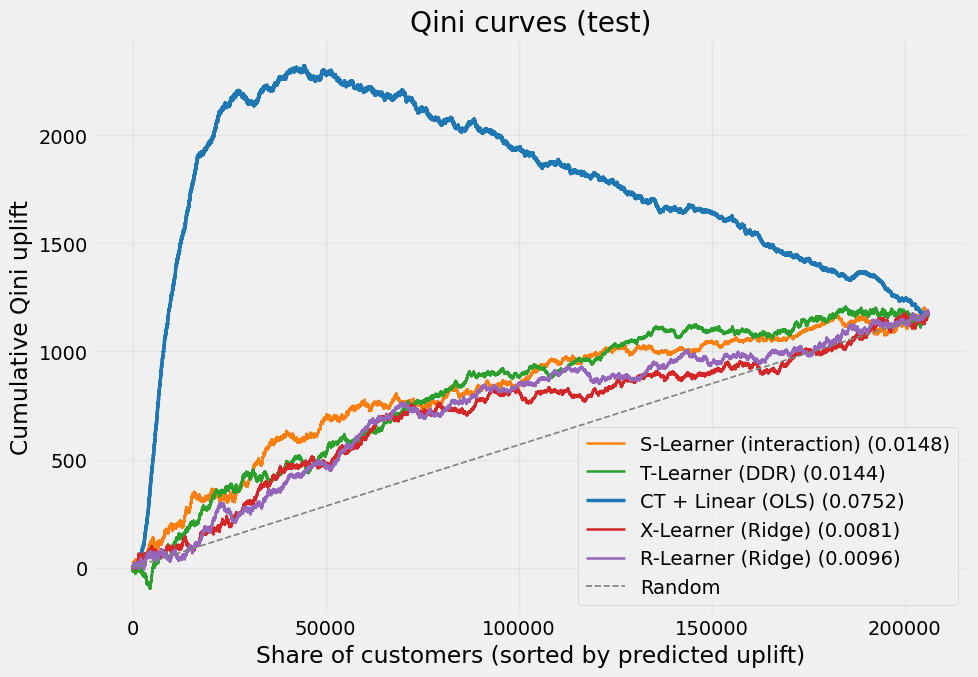

In [76]:
colors = {
    "S-Learner (interaction)": "#ff7f0e",
    "T-Learner (DDR)": "#2ca02c",
    "CT + Linear (OLS)": "#1f77b4",
    "X-Learner (Ridge)": "#d62728",
    "R-Learner (Ridge)": "#9467bd",
}

fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions.items():
    x_vals, y_vals = qini_curve(y_test, pred, treatment_test)
    last_x, last_y = x_vals, y_vals
    auc = qini_auc_score(y_test, pred, treatment_test)
    lw = 2.5 if name == "CT + Linear (OLS)" else 1.8
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=lw, label=f"{name} ({auc:.4f})")
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Qini curves (test)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative Qini uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

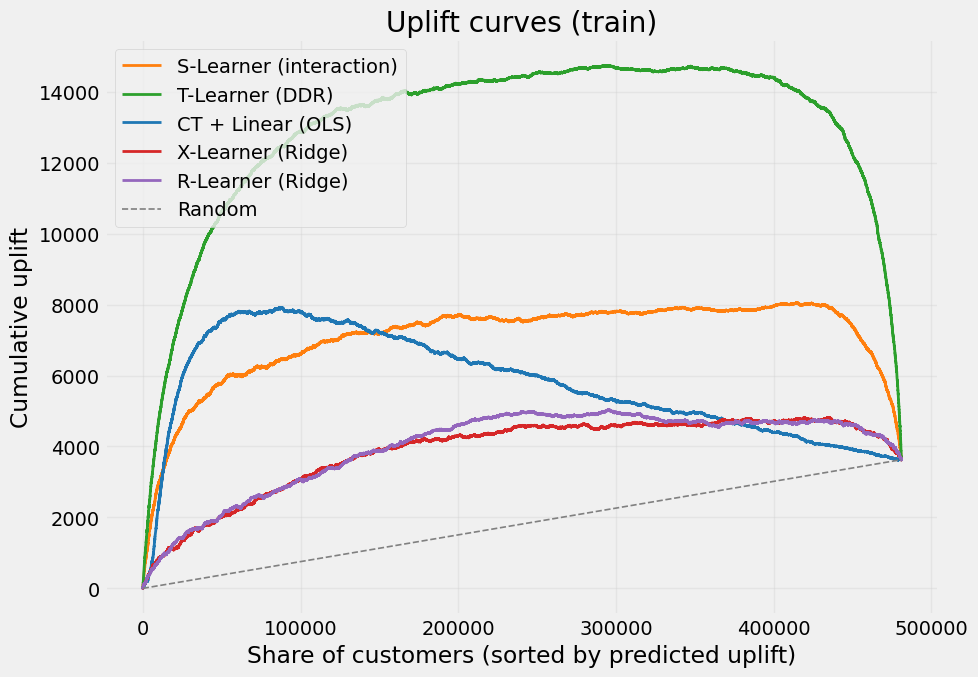

In [77]:
fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions_train.items():
    x_vals, y_vals = uplift_curve(y_train, pred, treatment_train)
    last_x, last_y = x_vals, y_vals
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=2, label=name)
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Uplift curves (train)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


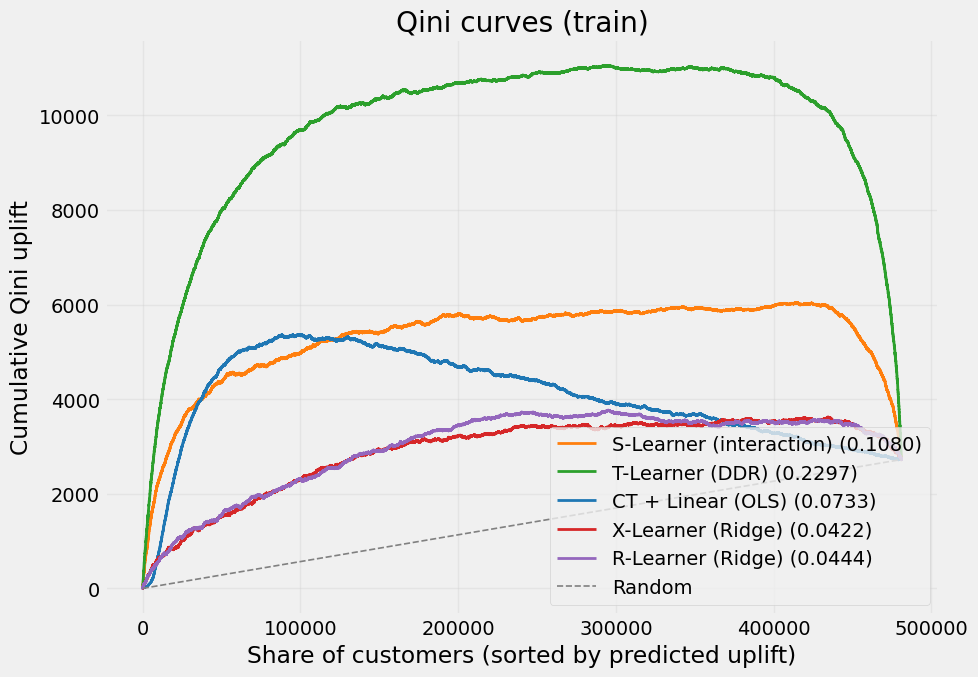

In [78]:
fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions_train.items():
    x_vals, y_vals = qini_curve(y_train, pred, treatment_train)
    last_x, last_y = x_vals, y_vals
    auc = qini_auc_score(y_train, pred, treatment_train)
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=2, label=f"{name} ({auc:.4f})")
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Qini curves (train)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative Qini uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


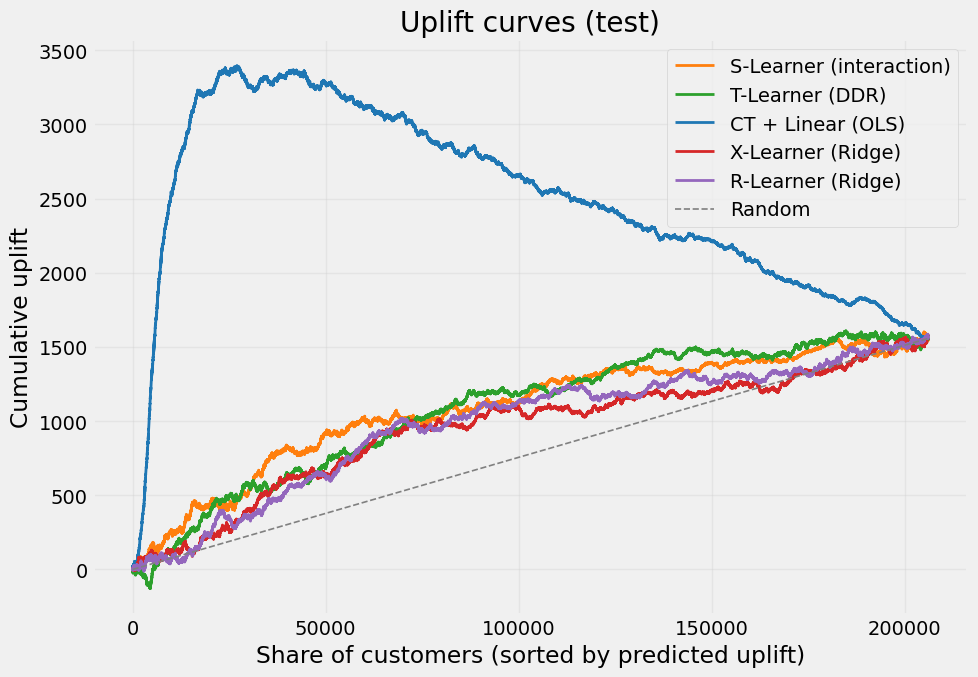

In [79]:
fig, ax = plt.subplots(figsize=(10, 7))
last_x = None
last_y = None
for name, pred in predictions.items():
    x_vals, y_vals = uplift_curve(y_test, pred, treatment_test)
    last_x, last_y = x_vals, y_vals
    ax.plot(x_vals, y_vals, color=colors.get(name), linewidth=2, label=name)
if last_x is not None:
    ax.plot([0, last_x[-1]], [0, last_y[-1]], color="gray", linestyle="--", linewidth=1.2, label="Random")
ax.set_title("Uplift curves (test)")
ax.set_xlabel("Share of customers (sorted by predicted uplift)")
ax.set_ylabel("Cumulative uplift")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


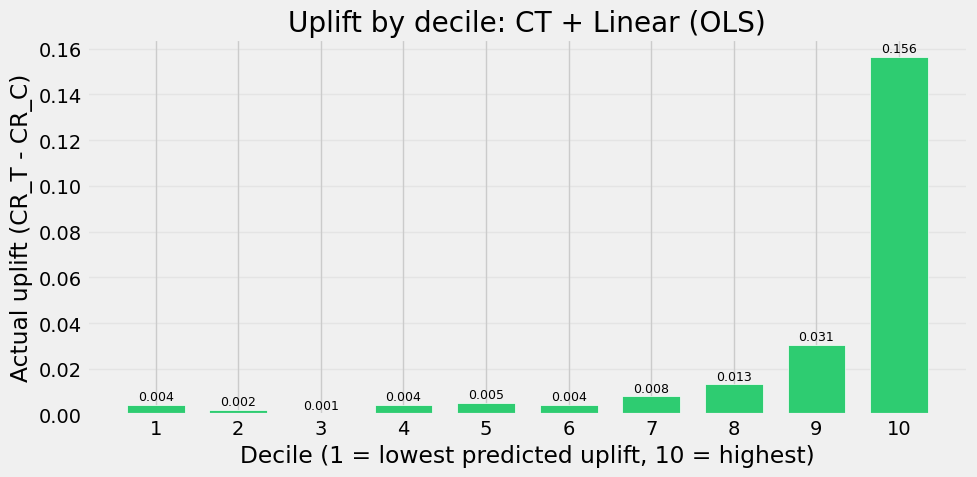

In [80]:
best_name = metrics_df_test.index[0]
best_pred = predictions[best_name]
bdf = decile_stats(best_pred, y_test, treatment_test, n_bins=10)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#2ecc71" if u > 0 else "#e74c3c" for u in bdf["Uplift"]]
ax.bar(bdf["Decile"], bdf["Uplift"], color=bar_colors, edgecolor="white", width=0.7)
ax.axhline(y=0, color="black", linewidth=0.8)
for _, row in bdf.iterrows():
    offset = 0.0008 if row["Uplift"] >= 0 else -0.0020
    ax.text(row["Decile"], row["Uplift"] + offset, f"{row['Uplift']:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Decile (1 = lowest predicted uplift, 10 = highest)")
ax.set_ylabel("Actual uplift (CR_T - CR_C)")
ax.set_title(f"Uplift by decile: {best_name}")
ax.set_xticks(bdf["Decile"])
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()


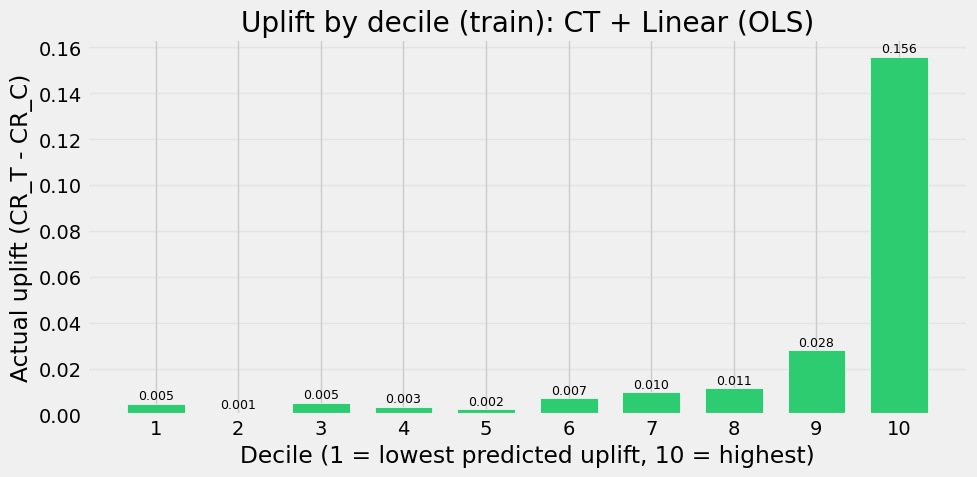

In [81]:
best_pred_train = predictions_train[best_name]
bdf_tr = decile_stats(best_pred_train, y_train, treatment_train, n_bins=10)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#2ecc71" if u > 0 else "#e74c3c" for u in bdf_tr["Uplift"]]
ax.bar(bdf_tr["Decile"], bdf_tr["Uplift"], color=bar_colors, edgecolor="white", width=0.7)
ax.axhline(y=0, color="black", linewidth=0.8)
for _, row in bdf_tr.iterrows():
    offset = 0.0008 if row["Uplift"] >= 0 else -0.0020
    ax.text(row["Decile"], row["Uplift"] + offset, f"{row['Uplift']:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Decile (1 = lowest predicted uplift, 10 = highest)")
ax.set_ylabel("Actual uplift (CR_T - CR_C)")
ax.set_title(f"Uplift by decile (train): {best_name}")
ax.set_xticks(bdf_tr["Decile"])
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()


Mean: 0.0063, Std: 0.0011
Min: 0.0045, Max: 0.0130
% positive uplift: 100.0%


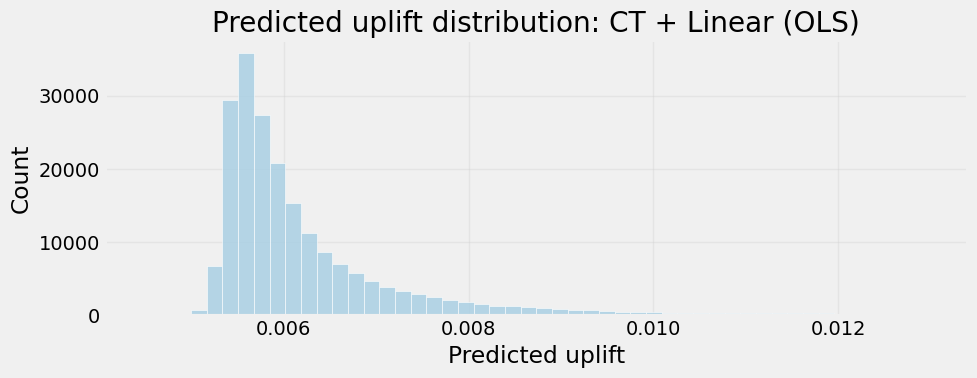

In [82]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(best_pred, bins=50, edgecolor="white", alpha=0.8)
ax.set_title(f"Predicted uplift distribution: {best_name}")
ax.set_xlabel("Predicted uplift")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()

print(f"Mean: {best_pred.mean():.4f}, Std: {best_pred.std():.4f}")
print(f"Min: {best_pred.min():.4f}, Max: {best_pred.max():.4f}")
print(f"% positive uplift: {(best_pred > 0).mean():.1%}")


Mean: 0.0063, Std: 0.0012
Min: 0.0044, Max: 0.0139
% positive uplift: 100.0%


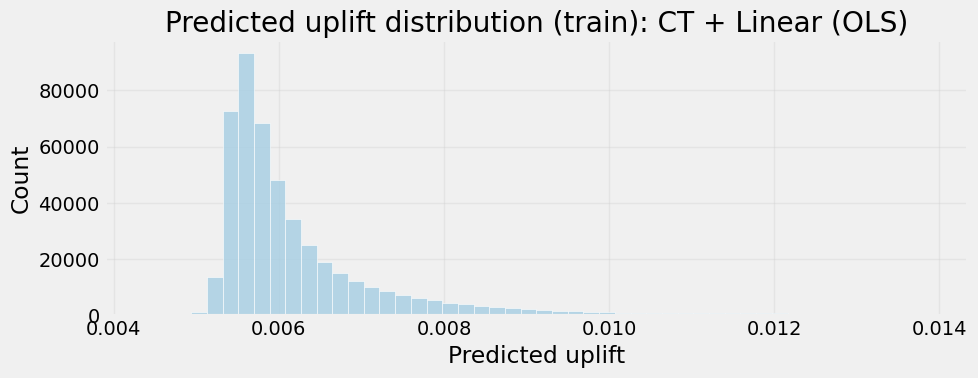

In [83]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(best_pred_train, bins=50, edgecolor="white", alpha=0.8)
ax.set_title(f"Predicted uplift distribution (train): {best_name}")
ax.set_xlabel("Predicted uplift")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)
plt.tight_layout()

print(f"Mean: {best_pred_train.mean():.4f}, Std: {best_pred_train.std():.4f}")
print(f"Min: {best_pred_train.min():.4f}, Max: {best_pred_train.max():.4f}")
print(f"% positive uplift: {(best_pred_train > 0).mean():.1%}")


## Experiment: Regularized X-Learner & R-Learner with Feature Selection

Current X/R-Learner problems:
- X-Learner: **negative** test Qini (−0.0013), overfit ∞
- R-Learner: test Qini = 0.0104, overfit 22.8×

Strategy:
1. **Feature selection** — keep only top-30 features by CT feature importance (remove noise from 210+ irrelevant features)
2. **Stronger regularization** — `max_depth=2`, `n_estimators=50`, `min_child_samples=500` (current: `max_depth=4`, `n_estimators=100`)

In [87]:
# ── Feature selection: top-30 by CT importance ──────────────────────────────
importances = ct_base.estimator.feature_importances_
feat_names = X_train.columns
top30_idx = np.argsort(importances)[::-1][:30]
top30_names = feat_names[top30_idx]
print("Top-30 features by CT importance:")
for i, idx in enumerate(top30_idx):
    print(f"  {i+1:2d}. {feat_names[idx]:<30s}  imp={importances[idx]}")

X_tr_30 = X_train[top30_names].values
X_te_30 = X_test[top30_names].values

Top-30 features by CT importance:
   1. k_var_cheque_3m                 imp=301
   2. response_viber                  imp=300
   3. months_from_register            imp=278
   4. age                             imp=243
   5. k_var_days_between_visits_3m    imp=238
   6. response_sms                    imp=234
   7. promo_share_15d                 imp=202
   8. k_var_disc_share_6m_g49         imp=184
   9. sale_sum_12m_g26                imp=171
  10. k_var_sku_price_6m_g49          imp=167
  11. food_share_1m                   imp=167
  12. k_var_disc_share_6m_g27         imp=165
  13. k_var_count_per_cheque_6m_g24   imp=164
  14. k_var_sku_price_3m_g49          imp=163
  15. stdev_days_between_visits_15d   imp=161
  16. food_share_15d                  imp=161
  17. k_var_disc_share_6m_g44         imp=159
  18. sale_sum_12m_g27                imp=159
  19. k_var_sku_price_3m_g34          imp=158
  20. disc_sum_6m_g34                 imp=158
  21. k_var_count_per_cheque_6m_g44   imp=157


In [88]:
# ── Propensity on top-30 features ────────────────────────────────────────────
prop30 = LGBMClassifier(n_estimators=50, max_depth=2, learning_rate=0.1,
                        random_state=42, verbose=-1, n_jobs=-1)
p30_train = cross_val_predict(prop30, X_tr_30, t_tr, cv=3, method="predict_proba")[:, 1]
prop30.fit(X_tr_30, t_tr)
p30_test = prop30.predict_proba(X_te_30)[:, 1]
p30_train_full = prop30.predict_proba(X_tr_30)[:, 1]
p30_train = np.clip(p30_train, 0.01, 0.99)
p30_test = np.clip(p30_test, 0.01, 0.99)
p30_train_full = np.clip(p30_train_full, 0.01, 0.99)
print(f"Propensity (top-30): mean={p30_train.mean():.4f}")

# ── Regularized base learner params ─────────────────────────────────────────
lgbm_reg_params = dict(
    n_estimators=50,
    max_depth=2,
    min_child_samples=500,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

# ── X-Learner (regularized, top-30) ────────────────────────────────────────
xl_reg = BaseXRegressor(learner=LGBMRegressor(**lgbm_reg_params))
xl_reg.fit(X=X_tr_30, treatment=t_tr, y=y_tr, p=p30_train)
xl_reg_test = xl_reg.predict(X=X_te_30, p=p30_test).flatten()
xl_reg_train = xl_reg.predict(X=X_tr_30, p=p30_train_full).flatten()
print(f"X-Learner (reg): Train Qini={qini_auc_score(y_train, xl_reg_train, treatment_train):.4f}, "
      f"Test Qini={qini_auc_score(y_test, xl_reg_test, treatment_test):.4f}")

# ── R-Learner (regularized, top-30) ────────────────────────────────────────
rl_reg = BaseRRegressor(learner=LGBMRegressor(**lgbm_reg_params))
rl_reg.fit(X=X_tr_30, treatment=t_tr, y=y_tr, p=p30_train)
rl_reg_test = rl_reg.predict(X=X_te_30).flatten()
rl_reg_train = rl_reg.predict(X=X_tr_30).flatten()
print(f"R-Learner (reg): Train Qini={qini_auc_score(y_train, rl_reg_train, treatment_train):.4f}, "
      f"Test Qini={qini_auc_score(y_test, rl_reg_test, treatment_test):.4f}")

Propensity (top-30): mean=0.7509
X-Learner (reg): Train Qini=-0.0117, Test Qini=-0.0222


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skle

R-Learner (reg): Train Qini=0.0414, Test Qini=0.0080


In [89]:
# ── Comparison: original (Ridge) vs regularized LGBM ─────────────────────────
comparison = pd.DataFrame([
    {"Model": "X-Learner (Ridge, main)",
     **evaluate_metrics(y_test, predictions["X-Learner (Ridge)"], treatment_test)},
    {"Model": "X-Learner (reg LGBM+top30)",
     **evaluate_metrics(y_test, xl_reg_test, treatment_test)},
    {"Model": "R-Learner (Ridge, main)",
     **evaluate_metrics(y_test, predictions["R-Learner (Ridge)"], treatment_test)},
    {"Model": "R-Learner (reg LGBM+top30)",
     **evaluate_metrics(y_test, rl_reg_test, treatment_test)},
    {"Model": "CT + Linear (OLS)",
     **evaluate_metrics(y_test, predictions["CT + Linear (OLS)"], treatment_test)},
]).set_index("Model")

comparison_train = pd.DataFrame([
    {"Model": "X-Learner (Ridge, main)",
     **evaluate_metrics(y_train, predictions_train["X-Learner (Ridge)"], treatment_train)},
    {"Model": "X-Learner (reg LGBM+top30)",
     **evaluate_metrics(y_train, xl_reg_train, treatment_train)},
    {"Model": "R-Learner (Ridge, main)",
     **evaluate_metrics(y_train, predictions_train["R-Learner (Ridge)"], treatment_train)},
    {"Model": "R-Learner (reg LGBM+top30)",
     **evaluate_metrics(y_train, rl_reg_train, treatment_train)},
    {"Model": "CT + Linear (OLS)",
     **evaluate_metrics(y_train, predictions_train["CT + Linear (OLS)"], treatment_train)},
]).set_index("Model")

print("TEST")
display(comparison)
print()
print("TRAIN")
display(comparison_train)
print()

# Overfit ratios
print("Overfit ratios (Train/Test Qini AUC):")
for name in comparison.index:
    q_tr = comparison_train.loc[name, "Qini AUC"]
    q_te = comparison.loc[name, "Qini AUC"]
    ratio = q_tr / q_te if q_te > 0 else float("inf")
    print(f"  {name:<30s}  Train={q_tr:.4f}  Test={q_te:.4f}  Ratio={ratio:.1f}x")

TEST


,uplift@10%,uplift@30%,Qini AUC,Uplift AUC,WAU,ASD
Model,,,,,,
"X-Learner (Ridge, main)",0.011305,0.013576,0.008124,0.004485,0.007560,0.000176
X-Learner (reg LGBM+top30),-0.000841,0.000527,-0.022168,-0.012183,0.007559,0.000166
"R-Learner (Ridge, main)",0.013440,0.014163,0.009581,0.005299,0.007560,0.000188
R-Learner (reg LGBM+top30),0.022984,0.011500,0.007990,0.004360,0.007560,0.000018
CT + Linear (OLS),0.178985,0.032686,0.075240,0.045669,0.007558,0.002229



TRAIN


,uplift@10%,uplift@30%,Qini AUC,Uplift AUC,WAU,ASD
Model,,,,,,
"X-Learner (Ridge, main)",0.041984,0.026108,0.042153,0.023238,0.007543,0.000016
X-Learner (reg LGBM+top30),0.004976,0.005543,-0.011746,-0.006514,0.007541,0.000095
"R-Learner (Ridge, main)",0.042114,0.026128,0.044419,0.024499,0.007543,0.000013
R-Learner (reg LGBM+top30),0.050460,0.027143,0.041392,0.022638,0.007543,0.000154
CT + Linear (OLS),0.171623,0.031899,0.073277,0.044619,0.007544,0.002197



Overfit ratios (Train/Test Qini AUC):
  X-Learner (Ridge, main)         Train=0.0422  Test=0.0081  Ratio=5.2x
  X-Learner (reg LGBM+top30)      Train=-0.0117  Test=-0.0222  Ratio=infx
  R-Learner (Ridge, main)         Train=0.0444  Test=0.0096  Ratio=4.6x
  R-Learner (reg LGBM+top30)      Train=0.0414  Test=0.0080  Ratio=5.2x
  CT + Linear (OLS)               Train=0.0733  Test=0.0752  Ratio=1.0x


In [90]:
# ── Experiment 2: moderate regularization LGBM, all 244 features ────────────
lgbm_mod_params = dict(
    n_estimators=100,
    max_depth=3,
    min_child_samples=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

# X-Learner (moderate reg, all features)
xl_mod = BaseXRegressor(learner=LGBMRegressor(**lgbm_mod_params))
xl_mod.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
xl_mod_test = xl_mod.predict(X=X_te, p=p_test).flatten()
xl_mod_train = xl_mod.predict(X=X_tr, p=p_train_full).flatten()

# R-Learner (moderate reg, all features)
rl_mod = BaseRRegressor(learner=LGBMRegressor(**lgbm_mod_params))
rl_mod.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
rl_mod_test = rl_mod.predict(X=X_te).flatten()
rl_mod_train = rl_mod.predict(X=X_tr).flatten()

# Results
comp2 = pd.DataFrame([
    {"Model": "X-Learner (Ridge, main)",
     **evaluate_metrics(y_test, predictions["X-Learner (Ridge)"], treatment_test)},
    {"Model": "X-Learner (reg LGBM: depth=2, top30)",
     **evaluate_metrics(y_test, xl_reg_test, treatment_test)},
    {"Model": "X-Learner (mod LGBM: depth=3, all feat)",
     **evaluate_metrics(y_test, xl_mod_test, treatment_test)},
    {"Model": "R-Learner (Ridge, main)",
     **evaluate_metrics(y_test, predictions["R-Learner (Ridge)"], treatment_test)},
    {"Model": "R-Learner (reg LGBM: depth=2, top30)",
     **evaluate_metrics(y_test, rl_reg_test, treatment_test)},
    {"Model": "R-Learner (mod LGBM: depth=3, all feat)",
     **evaluate_metrics(y_test, rl_mod_test, treatment_test)},
    {"Model": "CT + Linear (OLS)",
     **evaluate_metrics(y_test, predictions["CT + Linear (OLS)"], treatment_test)},
]).set_index("Model")

comp2_train = pd.DataFrame([
    {"Model": "X-Learner (Ridge, main)",
     **evaluate_metrics(y_train, predictions_train["X-Learner (Ridge)"], treatment_train)},
    {"Model": "X-Learner (reg LGBM: depth=2, top30)",
     **evaluate_metrics(y_train, xl_reg_train, treatment_train)},
    {"Model": "X-Learner (mod LGBM: depth=3, all feat)",
     **evaluate_metrics(y_train, xl_mod_train, treatment_train)},
    {"Model": "R-Learner (Ridge, main)",
     **evaluate_metrics(y_train, predictions_train["R-Learner (Ridge)"], treatment_train)},
    {"Model": "R-Learner (reg LGBM: depth=2, top30)",
     **evaluate_metrics(y_train, rl_reg_train, treatment_train)},
    {"Model": "R-Learner (mod LGBM: depth=3, all feat)",
     **evaluate_metrics(y_train, rl_mod_train, treatment_train)},
    {"Model": "CT + Linear (OLS)",
     **evaluate_metrics(y_train, predictions_train["CT + Linear (OLS)"], treatment_train)},
]).set_index("Model")

print("TEST")
display(comp2[["Qini AUC", "uplift@10%", "ASD"]])
print()
print("TRAIN")
display(comp2_train[["Qini AUC", "uplift@10%", "ASD"]])
print()
print("Overfit ratios (Qini AUC):")
for name in comp2.index:
    q_tr = comp2_train.loc[name, "Qini AUC"]
    q_te = comp2.loc[name, "Qini AUC"]
    ratio = q_tr / q_te if q_te > 0 else float("inf")
    print(f"  {name:<45s}  Train={q_tr:.4f}  Test={q_te:.4f}  Ratio={ratio:.1f}x")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skle

TEST


,Qini AUC,uplift@10%,ASD
Model,,,
"X-Learner (Ridge, main)",0.008124,0.011305,0.000176
"X-Learner (reg LGBM: depth=2, top30)",-0.022168,-0.000841,0.000166
"X-Learner (mod LGBM: depth=3, all feat)",-0.004504,0.015808,0.000134
"R-Learner (Ridge, main)",0.009581,0.013440,0.000188
"R-Learner (reg LGBM: depth=2, top30)",0.007990,0.022984,0.000018
"R-Learner (mod LGBM: depth=3, all feat)",0.005134,0.019379,0.000043
CT + Linear (OLS),0.075240,0.178985,0.002229



TRAIN


,Qini AUC,uplift@10%,ASD
Model,,,
"X-Learner (Ridge, main)",0.042153,0.041984,0.000016
"X-Learner (reg LGBM: depth=2, top30)",-0.011746,0.004976,0.000095
"X-Learner (mod LGBM: depth=3, all feat)",0.061754,0.066717,0.000401
"R-Learner (Ridge, main)",0.044419,0.042114,0.000013
"R-Learner (reg LGBM: depth=2, top30)",0.041392,0.050460,0.000154
"R-Learner (mod LGBM: depth=3, all feat)",0.124917,0.123709,0.001893
CT + Linear (OLS),0.073277,0.171623,0.002197



Overfit ratios (Qini AUC):
  X-Learner (Ridge, main)                        Train=0.0422  Test=0.0081  Ratio=5.2x
  X-Learner (reg LGBM: depth=2, top30)           Train=-0.0117  Test=-0.0222  Ratio=infx
  X-Learner (mod LGBM: depth=3, all feat)        Train=0.0618  Test=-0.0045  Ratio=infx
  R-Learner (Ridge, main)                        Train=0.0444  Test=0.0096  Ratio=4.6x
  R-Learner (reg LGBM: depth=2, top30)           Train=0.0414  Test=0.0080  Ratio=5.2x
  R-Learner (mod LGBM: depth=3, all feat)        Train=0.1249  Test=0.0051  Ratio=24.3x
  CT + Linear (OLS)                              Train=0.0733  Test=0.0752  Ratio=1.0x


In [91]:
# ── Experiment 3: Ridge alpha=1 & CatBoost as base learners ─────────────────
from sklearn.linear_model import Ridge as Ridge_
from catboost import CatBoostRegressor

# --- Ridge (alpha=1, low regularization for comparison) ---
xl_ridge1 = BaseXRegressor(learner=Ridge_(alpha=1.0))
xl_ridge1.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
xl_ridge1_te = xl_ridge1.predict(X=X_te, p=p_test).flatten()
xl_ridge1_tr = xl_ridge1.predict(X=X_tr, p=p_train_full).flatten()

rl_ridge1 = BaseRRegressor(learner=Ridge_(alpha=1.0))
rl_ridge1.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
rl_ridge1_te = rl_ridge1.predict(X=X_te).flatten()
rl_ridge1_tr = rl_ridge1.predict(X=X_tr).flatten()
print("Ridge (alpha=1) done")

# --- CatBoost (moderate regularization) ---
cb_params = dict(
    iterations=200, depth=4, learning_rate=0.05,
    l2_leaf_reg=10, min_data_in_leaf=200,
    random_state=42, verbose=0,
)

xl_cb = BaseXRegressor(learner=CatBoostRegressor(**cb_params))
xl_cb.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
xl_cb_te = xl_cb.predict(X=X_te, p=p_test).flatten()
xl_cb_tr = xl_cb.predict(X=X_tr, p=p_train_full).flatten()

rl_cb = BaseRRegressor(learner=CatBoostRegressor(**cb_params))
rl_cb.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
rl_cb_te = rl_cb.predict(X=X_te).flatten()
rl_cb_tr = rl_cb.predict(X=X_tr).flatten()
print("CatBoost done")

# --- Summary ---
rows = []
for label, te, tr in [
    ("X-Learner (Ridge α=1000, main)", predictions["X-Learner (Ridge)"], predictions_train["X-Learner (Ridge)"]),
    ("X-Learner (Ridge α=1)",          xl_ridge1_te, xl_ridge1_tr),
    ("X-Learner (CatBoost)",           xl_cb_te,    xl_cb_tr),
    ("R-Learner (Ridge α=100, main)",  predictions["R-Learner (Ridge)"], predictions_train["R-Learner (Ridge)"]),
    ("R-Learner (Ridge α=1)",          rl_ridge1_te, rl_ridge1_tr),
    ("R-Learner (CatBoost)",           rl_cb_te,    rl_cb_tr),
    ("CT + Linear (OLS)",              predictions["CT + Linear (OLS)"], predictions_train["CT + Linear (OLS)"]),
]:
    m_te = evaluate_metrics(y_test, te, treatment_test)
    m_tr = evaluate_metrics(y_train, tr, treatment_train)
    q_te, q_tr = m_te["Qini AUC"], m_tr["Qini AUC"]
    ratio = q_tr / q_te if q_te > 0 else float("inf")
    rows.append({"Model": label, "Test Qini": q_te, "Test uplift@10%": m_te["uplift@10%"],
                 "Test ASD": m_te["ASD"], "Train Qini": q_tr, "Overfit": f"{ratio:.1f}x"})

comp3 = pd.DataFrame(rows).set_index("Model")
display(comp3)

Ridge (alpha=1) done
CatBoost done


,Test Qini,Test uplift@10%,Test ASD,Train Qini,Overfit
Model,,,,,
"X-Learner (Ridge α=1000, main)",0.008124,0.011305,0.000176,0.042153,5.2x
X-Learner (Ridge α=1),0.006788,0.012564,0.000243,0.045145,6.7x
X-Learner (CatBoost),0.001865,0.011245,0.000066,0.100996,54.1x
"R-Learner (Ridge α=100, main)",0.009581,0.013440,0.000188,0.044419,4.6x
R-Learner (Ridge α=1),0.008893,0.012668,0.000212,0.044909,5.0x
R-Learner (CatBoost),0.008200,0.022177,0.000050,0.179953,21.9x
CT + Linear (OLS),0.075240,0.178985,0.002229,0.073277,1.0x


In [92]:
# ── Experiment 4: Ridge alpha grid search ────────────────────────────────────
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in alphas:
    # X-Learner
    xl_r = BaseXRegressor(learner=Ridge(alpha=alpha))
    xl_r.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
    xl_te = xl_r.predict(X=X_te, p=p_test).flatten()
    xl_tr_p = xl_r.predict(X=X_tr, p=p_train_full).flatten()
    q_te_xl = qini_auc_score(y_test, xl_te, treatment_test)
    q_tr_xl = qini_auc_score(y_train, xl_tr_p, treatment_train)
    u10_xl = uplift_at_k(y_test, xl_te, treatment_test, strategy="by_group", k=0.1)

    # R-Learner
    rl_r = BaseRRegressor(learner=Ridge(alpha=alpha))
    rl_r.fit(X=X_tr, treatment=t_tr, y=y_tr, p=p_train)
    rl_te = rl_r.predict(X=X_te).flatten()
    rl_tr_p = rl_r.predict(X=X_tr).flatten()
    q_te_rl = qini_auc_score(y_test, rl_te, treatment_test)
    q_tr_rl = qini_auc_score(y_train, rl_tr_p, treatment_train)
    u10_rl = uplift_at_k(y_test, rl_te, treatment_test, strategy="by_group", k=0.1)

    ridge_results.append({
        "alpha": alpha,
        "X Test Qini": q_te_xl, "X Train Qini": q_tr_xl, "X uplift@10%": u10_xl,
        "X Overfit": f"{q_tr_xl/q_te_xl:.1f}x" if q_te_xl > 0 else "inf",
        "R Test Qini": q_te_rl, "R Train Qini": q_tr_rl, "R uplift@10%": u10_rl,
        "R Overfit": f"{q_tr_rl/q_te_rl:.1f}x" if q_te_rl > 0 else "inf",
    })
    print(f"alpha={alpha:<6}  X: Test Qini={q_te_xl:+.4f} Train={q_tr_xl:.4f}  |  "
          f"R: Test Qini={q_te_rl:+.4f} Train={q_tr_rl:.4f}")

rdf = pd.DataFrame(ridge_results).set_index("alpha")
display(rdf)

alpha=0.01    X: Test Qini=+0.0068 Train=0.0451  |  R: Test Qini=+0.0089 Train=0.0449
alpha=0.1     X: Test Qini=+0.0068 Train=0.0451  |  R: Test Qini=+0.0087 Train=0.0449
alpha=1       X: Test Qini=+0.0068 Train=0.0451  |  R: Test Qini=+0.0090 Train=0.0450
alpha=10      X: Test Qini=+0.0069 Train=0.0451  |  R: Test Qini=+0.0091 Train=0.0449
alpha=100     X: Test Qini=+0.0073 Train=0.0444  |  R: Test Qini=+0.0094 Train=0.0443
alpha=1000    X: Test Qini=+0.0081 Train=0.0422  |  R: Test Qini=+0.0090 Train=0.0426


,X Test Qini,X Train Qini,X uplift@10%,X Overfit,R Test Qini,R Train Qini,R uplift@10%,R Overfit
alpha,,,,,,,,
0.01,0.006803,0.045149,0.012432,6.6x,0.008932,0.044872,0.012537,5.0x
0.10,0.006803,0.045147,0.012368,6.6x,0.008674,0.044894,0.012669,5.2x
1.00,0.006788,0.045145,0.012564,6.7x,0.008993,0.045027,0.013510,5.0x
10.00,0.006948,0.045071,0.012432,6.5x,0.009135,0.044939,0.012536,4.9x
100.00,0.007323,0.044408,0.011712,6.1x,0.009356,0.044314,0.012921,4.7x
1000.00,0.008124,0.042153,0.011305,5.2x,0.009050,0.042569,0.014770,4.7x
